El Harraj Imane (GLCC)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [9]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

In [10]:
X, y = datasets.make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=2, random_state=40)
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [11]:
clf = SVM(n_iters=1000)
clf.fit(X_train, y_train)

In [12]:
def visualize_svm():
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x - b + offset) / w[1]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X[:, 0], X[:, 1], marker='o', c=y)

    x0_1 = np.amin(X[:, 0])
    x0_2 = np.amax(X[:, 0])

    y1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
    y2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)

    y1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
    y2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)

    y1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
    y2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)

    ax.plot([x0_1, x0_2], [y1, y2], 'r', label="Hyperplan")
    ax.plot([x0_1, x0_2], [y1_m, y2_m], 'k--', label="Marge -")
    ax.plot([x0_1, x0_2], [y1_p, y2_p], 'k--', label="Marge +")

    x1_min = np.amin(X[:, 1])
    x1_max = np.amax(X[:, 1])
    ax.set_ylim([x1_min - 3, x1_max + 3])

    plt.title("SVM Scratch: Maximisation de la Marge")
    plt.legend()
    plt.show()



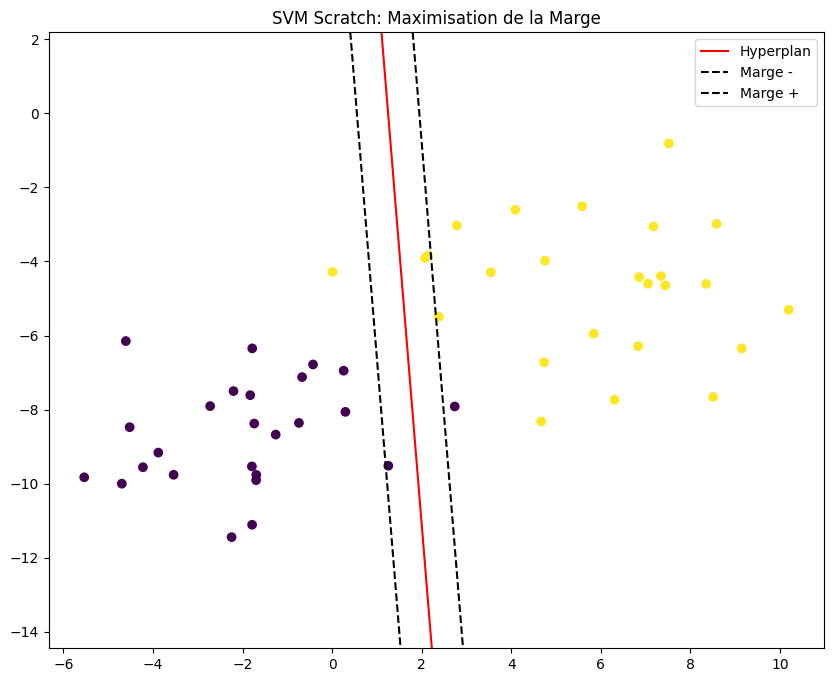

In [13]:
visualize_svm()

In [14]:
predictions = clf.predict(X_test)
